# 04b — Model Improvements: xG Ablation, Regularisation & Regime Analysis

**Phase 4b follow-up to notebook 04 (Baseline Model).**

This notebook extends the Phase 4 baseline analysis with three investigations:

| Section | Question |
|---------|----------|
| **A. xG Ablation Study** | Do xG features add predictive value beyond shots/SOT already present? |
| **B. Model Improvement Experiments** | Can reduced features, regularisation, or recalibration fix LGBM overfitting (BSS = −0.29)? |
| **C. 2023/24 Structural Break Deep-Dive** | What drives the 2023/24 prediction penalty, and can regime-aware weighting help? |

**Key constraints:**
- No changes to `src/` modules — everything built in-notebook.
- Market LR is re-run here for exact comparability.
- 6 figures saved to `reports/figures/04b_*.png`.

---

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats as sp_stats

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.isotonic import IsotonicRegression

try:
    import lightgbm as lgb
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
    print(f'LightGBM {lgb.__version__} available.')
except ImportError:
    LGBM_AVAILABLE = False
    print('LightGBM not available — install with: pip install lightgbm')

from src.utils.config import DB_PATH
from src.utils.db import run_query
from src.modeling.features import (
    prepare, FEATURE_SETS,
    ROLLING_FEATURES, CONTEXT_FEATURES, ELO_FEATURES, MARKET_FEATURES,
)
from src.modeling.evaluate import compute_metrics, calibration_bins, metrics_table
from src.modeling.walk_forward import (
    walk_forward_cv, aggregate_cv_results,
    results_to_dataframe, predictions_dataframe,
)

# ── Plot style ─────────────────────────────────────────────────────────────
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
sns.set_palette('tab10')
PALETTE = sns.color_palette('tab10')

FIGURES_DIR = Path('../reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'DB path  : {DB_PATH}')
print(f'Figures  : {FIGURES_DIR.resolve()}')

LightGBM 4.6.0 available.
DB path  : C:\Users\USER\Documents\Python Projects\bet-intelligence\data\db\bet_intelligence.duckdb
Figures  : C:\Users\USER\Documents\Python Projects\bet-intelligence\reports\figures


In [2]:
# ── Load data (identical to notebook 04) ──────────────────────────────────
SQL = '''
    SELECT ef.*, m.over_25, m.season, m.kickoff_utc
    FROM engineered_features ef
    JOIN matches m ON ef.match_id = m.match_id
    ORDER BY m.kickoff_utc
'''

df = run_query(SQL)
df['over_25']     = df['over_25'].astype(float)
df['kickoff_utc'] = pd.to_datetime(df['kickoff_utc'], utc=True)

seasons   = sorted(df['season'].unique())
base_rate = df['over_25'].mean()

print(f'Shape            : {df.shape}')
print(f'Seasons          : {seasons}')
print(f'Base rate (O2.5) : {base_rate:.4f}  ({base_rate * 100:.1f}%)')

# ── Prepare standard feature sets ─────────────────────────────────────────
X_market, y_market = prepare(df, 'market_only', drop_nan_rows=True)
X_form,   y_form   = prepare(df, 'form_only',   drop_nan_rows=True)
X_all,    y_all    = prepare(df, 'all',          drop_nan_rows=True)

# ── Walk-forward fold reference ───────────────────────────────────────────
TEST_SEASONS = ['2020/21', '2021/22', '2022/23', '2023/24']

for name, X, y in [('market_only', X_market, y_market),
                    ('form_only',   X_form,   y_form),
                    ('all',         X_all,    y_all)]:
    print(f'  {name:<14}  {X.shape[1]:>3} features  {len(X):>5} rows  base_rate={y.mean():.4f}')

Shape            : (1900, 57)
Seasons          : ['2019/20', '2020/21', '2021/22', '2022/23', '2023/24']
Base rate (O2.5) : 0.5468  (54.7%)
  market_only       1 features   1891 rows  base_rate=0.5457
  form_only        32 features   1884 rows  base_rate=0.5462
  all              43 features   1874 rows  base_rate=0.5448


In [3]:
# ── Re-run Market LR baseline for exact comparability ─────────────────────
def make_market_lr():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(C=1.0, max_iter=1000, random_state=42)),
    ])

market_results = walk_forward_cv(
    df=df, X=X_market, y=y_market, model_fn=make_market_lr, label='Market LR (PIN)',
)
market_agg   = aggregate_cv_results(market_results)
market_preds = predictions_dataframe(market_results)

print('── Market LR (PIN) Baseline ─────────────────────────────────────────')
print(metrics_table([r['metrics'] for r in market_results]).to_string(index=False))
print(f'\nMean AUC = {market_agg["roc_auc_mean"]:.4f}  '
      f'Mean BSS = {market_agg["bss_mean"]:.4f}')

── Market LR (PIN) Baseline ─────────────────────────────────────────
          label   n  base_rate  roc_auc  brier     bss  log_loss
Market LR (PIN) 380     0.5000   0.5682 0.2507 -0.0029    0.6958
Market LR (PIN) 380     0.5395   0.5711 0.2459  0.0101    0.6849
Market LR (PIN) 379     0.5251   0.6236 0.2386  0.0432    0.6698
Market LR (PIN) 372     0.6452   0.5788 0.2293 -0.0018    0.6507

Mean AUC = 0.5854  Mean BSS = 0.0121


---
## Section A — xG Ablation Study

The `form_only` and `all` feature sets include 4 xG rolling features:
`home_xg_for_avg5`, `home_xg_against_avg5`, `away_xg_for_avg5`, `away_xg_against_avg5`.

These were ingested from Understat in Phase 4b. The question: **do xG features add
anything beyond the shots/SOT features already present?**

Protocol:
1. Create `form_only_no_xg` and `all_no_xg` by filtering out the 4 xG columns.
2. Run walk-forward CV with Form LR on `form_only` (with xG) vs `form_only_no_xg`.
3. Run walk-forward CV with LightGBM on `all` vs `all_no_xg`.
4. Compare AUC / Brier / BSS per fold.

In [4]:
# ── Define xG-ablated feature sets ────────────────────────────────────────
XG_FEATURES = [
    'home_xg_for_avg5', 'home_xg_against_avg5',
    'away_xg_for_avg5', 'away_xg_against_avg5',
]

form_only_no_xg_cols = [c for c in FEATURE_SETS['form_only'] if c not in XG_FEATURES]
all_no_xg_cols       = [c for c in FEATURE_SETS['all']       if c not in XG_FEATURES]

print(f'form_only     : {len(FEATURE_SETS["form_only"]):>3} features')
print(f'form_only_no_xg: {len(form_only_no_xg_cols):>3} features  (delta = -{len(FEATURE_SETS["form_only"]) - len(form_only_no_xg_cols)})')
print(f'all           : {len(FEATURE_SETS["all"]):>3} features')
print(f'all_no_xg     : {len(all_no_xg_cols):>3} features  (delta = -{len(FEATURE_SETS["all"]) - len(all_no_xg_cols)})')

# ── Prepare ablated feature matrices ──────────────────────────────────────
# form_only_no_xg
available_fnx = [c for c in form_only_no_xg_cols if c in df.columns]
X_form_no_xg  = df[available_fnx].copy().apply(pd.to_numeric, errors='coerce')
mask_fnx      = X_form_no_xg.notna().all(axis=1)
X_form_no_xg  = X_form_no_xg.loc[mask_fnx]
y_form_no_xg  = df.loc[X_form_no_xg.index, 'over_25']

# all_no_xg
available_anx = [c for c in all_no_xg_cols if c in df.columns]
X_all_no_xg   = df[available_anx].copy().apply(pd.to_numeric, errors='coerce')
mask_anx      = X_all_no_xg.notna().all(axis=1)
X_all_no_xg   = X_all_no_xg.loc[mask_anx]
y_all_no_xg   = df.loc[X_all_no_xg.index, 'over_25']

print(f'\nX_form_no_xg : {X_form_no_xg.shape}  y base_rate = {y_form_no_xg.mean():.4f}')
print(f'X_all_no_xg  : {X_all_no_xg.shape}  y base_rate = {y_all_no_xg.mean():.4f}')

form_only     :  32 features
form_only_no_xg:  28 features  (delta = -4)
all           :  43 features
all_no_xg     :  39 features  (delta = -4)

X_form_no_xg : (1884, 28)  y base_rate = 0.5462
X_all_no_xg  : (1874, 39)  y base_rate = 0.5448


In [5]:
# ── Form LR: with xG vs without xG ───────────────────────────────────────
def make_form_lr():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(C=1.0, max_iter=2000, random_state=42)),
    ])

form_xg_results = walk_forward_cv(
    df=df, X=X_form, y=y_form, model_fn=make_form_lr, label='Form LR (with xG)',
)
form_no_xg_results = walk_forward_cv(
    df=df, X=X_form_no_xg, y=y_form_no_xg, model_fn=make_form_lr, label='Form LR (no xG)',
)

print('── Form LR WITH xG ─────────────────────────────────────────────────')
print(metrics_table([r['metrics'] for r in form_xg_results]).to_string(index=False))
print(f'Mean AUC = {aggregate_cv_results(form_xg_results)["roc_auc_mean"]:.4f}')
print()
print('── Form LR WITHOUT xG ──────────────────────────────────────────────')
print(metrics_table([r['metrics'] for r in form_no_xg_results]).to_string(index=False))
print(f'Mean AUC = {aggregate_cv_results(form_no_xg_results)["roc_auc_mean"]:.4f}')

── Form LR WITH xG ─────────────────────────────────────────────────
            label   n  base_rate  roc_auc  brier     bss  log_loss
Form LR (with xG) 377     0.4960   0.5722 0.2533 -0.0134    0.7038
Form LR (with xG) 379     0.5409   0.5198 0.2600 -0.0472    0.7216
Form LR (with xG) 379     0.5277   0.5349 0.2524 -0.0127    0.6992
Form LR (with xG) 379     0.6464   0.5507 0.2328 -0.0186    0.6585
Mean AUC = 0.5444

── Form LR WITHOUT xG ──────────────────────────────────────────────
          label   n  base_rate  roc_auc  brier     bss  log_loss
Form LR (no xG) 377     0.4960   0.5697 0.2540 -0.0161    0.7053
Form LR (no xG) 379     0.5409   0.5017 0.2611 -0.0516    0.7208
Form LR (no xG) 379     0.5277   0.5260 0.2524 -0.0127    0.6998
Form LR (no xG) 379     0.6464   0.5224 0.2406 -0.0526    0.6748
Mean AUC = 0.5300


In [6]:
# ── LightGBM: with xG vs without xG ──────────────────────────────────────
if LGBM_AVAILABLE:
    def make_lgbm_baseline():
        return LGBMClassifier(
            n_estimators=300, learning_rate=0.05, num_leaves=31,
            min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbose=-1,
        )

    lgbm_xg_results = walk_forward_cv(
        df=df, X=X_all, y=y_all, model_fn=make_lgbm_baseline, label='LGBM (with xG)',
    )
    lgbm_no_xg_results = walk_forward_cv(
        df=df, X=X_all_no_xg, y=y_all_no_xg, model_fn=make_lgbm_baseline, label='LGBM (no xG)',
    )

    print('── LGBM WITH xG ────────────────────────────────────────────────────')
    print(metrics_table([r['metrics'] for r in lgbm_xg_results]).to_string(index=False))
    print(f'Mean AUC = {aggregate_cv_results(lgbm_xg_results)["roc_auc_mean"]:.4f}')
    print()
    print('── LGBM WITHOUT xG ─────────────────────────────────────────────────')
    print(metrics_table([r['metrics'] for r in lgbm_no_xg_results]).to_string(index=False))
    print(f'Mean AUC = {aggregate_cv_results(lgbm_no_xg_results)["roc_auc_mean"]:.4f}')
else:
    print('LightGBM not available — skipping ablation.')
    lgbm_xg_results = lgbm_no_xg_results = []

── LGBM WITH xG ────────────────────────────────────────────────────
         label   n  base_rate  roc_auc  brier     bss  log_loss
LGBM (with xG) 377     0.4960   0.5366 0.3365 -0.3462    1.0206
LGBM (with xG) 378     0.5397   0.5194 0.3335 -0.3424    0.9776
LGBM (with xG) 378     0.5265   0.5363 0.3066 -0.2300    0.8831
LGBM (with xG) 371     0.6442   0.5083 0.2837 -0.2376    0.8162
Mean AUC = 0.5252

── LGBM WITHOUT xG ─────────────────────────────────────────────────
       label   n  base_rate  roc_auc  brier     bss  log_loss
LGBM (no xG) 377     0.4960   0.5341 0.3382 -0.3527    1.0454
LGBM (no xG) 378     0.5397   0.5273 0.3297 -0.3273    0.9699
LGBM (no xG) 378     0.5265   0.5073 0.3179 -0.2752    0.9068
LGBM (no xG) 371     0.6442   0.5176 0.2765 -0.2062    0.7904
Mean AUC = 0.5216


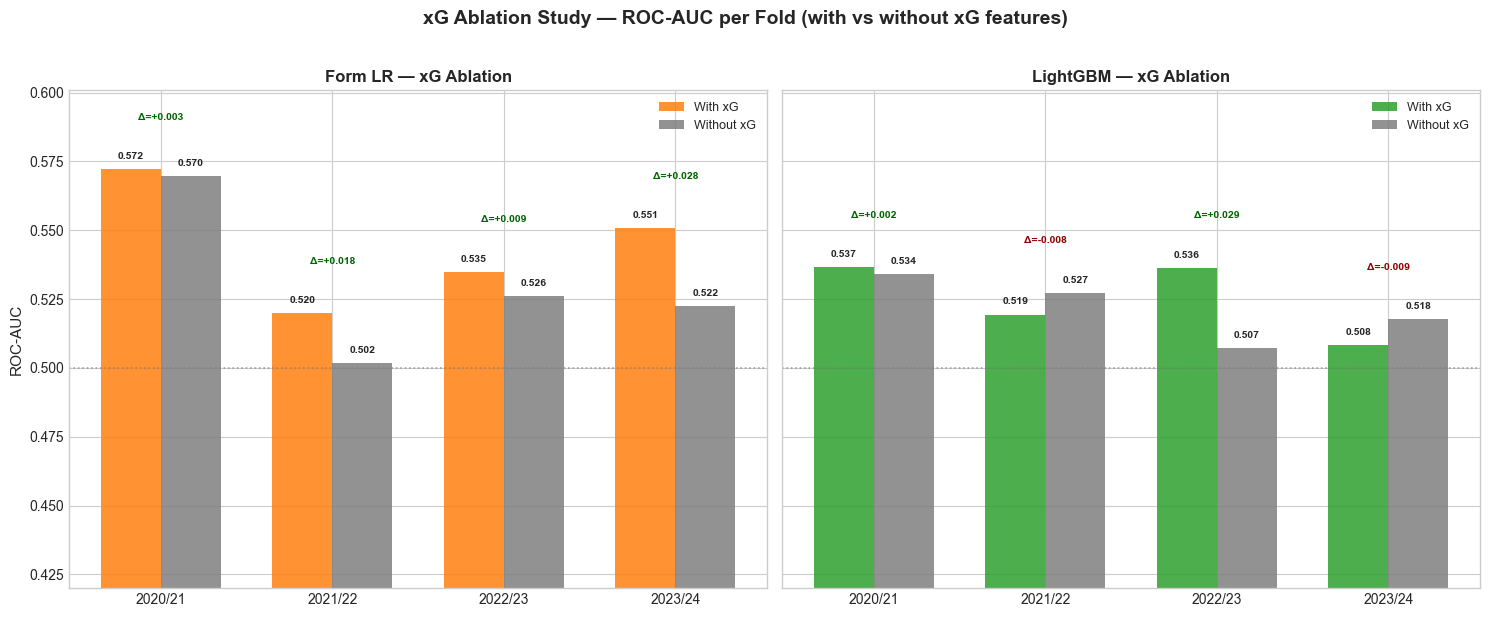

Saved: 04b_xg_ablation.png


In [7]:
# ── Figure 1: xG Ablation — 2-panel grouped bar chart ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

metrics_to_plot = ['roc_auc', 'brier', 'bss']
metric_labels   = {'roc_auc': 'ROC-AUC', 'brier': 'Brier', 'bss': 'BSS'}

# Panel 1: Form LR
ax = axes[0]
form_xg_folds    = [r['metrics'] for r in form_xg_results]
form_no_xg_folds = [r['metrics'] for r in form_no_xg_results]

x_pos  = np.arange(len(TEST_SEASONS))
width  = 0.35

auc_xg    = [m['roc_auc'] for m in form_xg_folds]
auc_no_xg = [m['roc_auc'] for m in form_no_xg_folds]

bars1 = ax.bar(x_pos - width/2, auc_xg,    width, label='With xG',    color=PALETTE[1], alpha=0.85)
bars2 = ax.bar(x_pos + width/2, auc_no_xg, width, label='Without xG', color=PALETTE[7], alpha=0.85)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003, f'{h:.3f}',
                ha='center', va='bottom', fontsize=7.5, fontweight='bold')

# Delta annotations
for i, (v1, v2) in enumerate(zip(auc_xg, auc_no_xg)):
    delta = v1 - v2
    y_pos = max(v1, v2) + 0.018
    ax.text(x_pos[i], y_pos, f'Δ={delta:+.3f}', ha='center', fontsize=7.5,
            color='darkgreen' if delta > 0 else 'darkred', fontweight='bold')

ax.axhline(0.5, color='grey', linestyle=':', linewidth=1.2, alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(TEST_SEASONS, fontsize=10)
ax.set_ylabel('ROC-AUC', fontsize=11)
ax.set_title('Form LR — xG Ablation', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0.42, None)

# Panel 2: LightGBM
ax = axes[1]
if LGBM_AVAILABLE and lgbm_xg_results and lgbm_no_xg_results:
    lgbm_xg_folds    = [r['metrics'] for r in lgbm_xg_results]
    lgbm_no_xg_folds = [r['metrics'] for r in lgbm_no_xg_results]

    auc_xg_l    = [m['roc_auc'] for m in lgbm_xg_folds]
    auc_no_xg_l = [m['roc_auc'] for m in lgbm_no_xg_folds]

    bars3 = ax.bar(x_pos - width/2, auc_xg_l,    width, label='With xG',    color=PALETTE[2], alpha=0.85)
    bars4 = ax.bar(x_pos + width/2, auc_no_xg_l, width, label='Without xG', color=PALETTE[7], alpha=0.85)

    for bars in [bars3, bars4]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.003, f'{h:.3f}',
                    ha='center', va='bottom', fontsize=7.5, fontweight='bold')

    for i, (v1, v2) in enumerate(zip(auc_xg_l, auc_no_xg_l)):
        delta = v1 - v2
        y_pos = max(v1, v2) + 0.018
        ax.text(x_pos[i], y_pos, f'Δ={delta:+.3f}', ha='center', fontsize=7.5,
                color='darkgreen' if delta > 0 else 'darkred', fontweight='bold')
else:
    ax.text(0.5, 0.5, 'LightGBM not available', transform=ax.transAxes,
            ha='center', va='center', fontsize=13, color='grey')

ax.axhline(0.5, color='grey', linestyle=':', linewidth=1.2, alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(TEST_SEASONS, fontsize=10)
ax.set_title('LightGBM — xG Ablation', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

fig.suptitle('xG Ablation Study — ROC-AUC per Fold (with vs without xG features)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04b_xg_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04b_xg_ablation.png')

In [8]:
# ── xG Ablation Verdict ───────────────────────────────────────────────────
agg_with    = aggregate_cv_results(form_xg_results)
agg_without = aggregate_cv_results(form_no_xg_results)
form_delta  = agg_with['roc_auc_mean'] - agg_without['roc_auc_mean']

print('── xG Ablation Summary (Form LR) ───────────────────────────────────')
print(f'  With xG    : AUC = {agg_with["roc_auc_mean"]:.4f}  BSS = {agg_with["bss_mean"]:.4f}')
print(f'  Without xG : AUC = {agg_without["roc_auc_mean"]:.4f}  BSS = {agg_without["bss_mean"]:.4f}')
print(f'  Delta AUC  : {form_delta:+.4f}')
print()

if LGBM_AVAILABLE and lgbm_xg_results and lgbm_no_xg_results:
    agg_l_with    = aggregate_cv_results(lgbm_xg_results)
    agg_l_without = aggregate_cv_results(lgbm_no_xg_results)
    lgbm_delta    = agg_l_with['roc_auc_mean'] - agg_l_without['roc_auc_mean']
    print('── xG Ablation Summary (LightGBM) ──────────────────────────────────')
    print(f'  With xG    : AUC = {agg_l_with["roc_auc_mean"]:.4f}  BSS = {agg_l_with["bss_mean"]:.4f}')
    print(f'  Without xG : AUC = {agg_l_without["roc_auc_mean"]:.4f}  BSS = {agg_l_without["bss_mean"]:.4f}')
    print(f'  Delta AUC  : {lgbm_delta:+.4f}')
    print()

print('── Verdict ─────────────────────────────────────────────────────────')
if abs(form_delta) < 0.005:
    print('xG features provide negligible lift (<0.5 pp AUC). Shots/SOT already')
    print('capture most of the shot-quality signal. xG can be safely dropped for')
    print('parsimony without meaningful loss.')
elif form_delta > 0.005:
    print(f'xG features add {form_delta*100:.1f} pp AUC — a meaningful lift above shots/SOT alone.')
    print('Retain xG features in the primary feature set.')
else:
    print(f'xG features HURT performance by {abs(form_delta)*100:.1f} pp AUC.')
    print('Possible multicollinearity with shots/SOT — consider dropping xG or shots, not both.')

── xG Ablation Summary (Form LR) ───────────────────────────────────
  With xG    : AUC = 0.5444  BSS = -0.0230
  Without xG : AUC = 0.5300  BSS = -0.0333
  Delta AUC  : +0.0144

── xG Ablation Summary (LightGBM) ──────────────────────────────────
  With xG    : AUC = 0.5252  BSS = -0.2890
  Without xG : AUC = 0.5216  BSS = -0.2903
  Delta AUC  : +0.0036

── Verdict ─────────────────────────────────────────────────────────
xG features add 1.4 pp AUC — a meaningful lift above shots/SOT alone.
Retain xG features in the primary feature set.


---
## Section B — Model Improvement Experiments

The baseline LightGBM from notebook 04 overfits badly: **BSS ≈ −0.29** (worse than
the naive baseline). With only ~380–1520 training rows and 43 features, the GBDT
memorises noise.

Four LGBM variants are tested:

| Variant | Strategy |
|---------|----------|
| **LGBM-reduced** | Top 12 features by gain importance from notebook 04 |
| **LGBM-regularized** | All features + strong regularisation hyperparams |
| **LGBM-reduced-reg** | Both: reduced features + regularisation |
| **LGBM-recalibrated** | Best variant above + isotonic recalibration |

In [9]:
# ── Define reduced feature set (top 12 by gain from notebook 04) ──────────
REDUCED_FEATURES = [
    'home_elo',
    'elo_differential',
    'pin_b365_divergence',
    'away_elo',
    'pin_margin',
    'away_shots_avg5',
    'home_shots_avg5',
    'attack_proxy',
    'away_shots_on_target_avg5',
    'home_shots_on_target_avg5',
    'pin_implied_prob_over',
    'combined_goals_avg5',
]

# Prepare reduced feature matrix
available_red = [c for c in REDUCED_FEATURES if c in df.columns]
X_reduced     = df[available_red].copy().apply(pd.to_numeric, errors='coerce')
mask_red      = X_reduced.notna().all(axis=1)
X_reduced     = X_reduced.loc[mask_red]
y_reduced     = df.loc[X_reduced.index, 'over_25']

print(f'Reduced feature set: {len(REDUCED_FEATURES)} features')
for f in REDUCED_FEATURES:
    status = '✓' if f in df.columns else '✗ MISSING'
    print(f'  {status}  {f}')
print(f'\nX_reduced: {X_reduced.shape}  base_rate = {y_reduced.mean():.4f}')

Reduced feature set: 12 features
  ✓  home_elo
  ✓  elo_differential
  ✓  pin_b365_divergence
  ✓  away_elo
  ✓  pin_margin
  ✓  away_shots_avg5
  ✓  home_shots_avg5
  ✓  attack_proxy
  ✓  away_shots_on_target_avg5
  ✓  home_shots_on_target_avg5
  ✓  pin_implied_prob_over
  ✓  combined_goals_avg5

X_reduced: (1874, 12)  base_rate = 0.5448


In [10]:
# ── Variant 1: LGBM-reduced (top 12 features, baseline hyperparams) ──────
if LGBM_AVAILABLE:
    def make_lgbm_reduced():
        return LGBMClassifier(
            n_estimators=300, learning_rate=0.05, num_leaves=31,
            min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbose=-1,
        )

    reduced_results = walk_forward_cv(
        df=df, X=X_reduced, y=y_reduced, model_fn=make_lgbm_reduced, label='LGBM-reduced',
    )
    print('── LGBM-reduced (12 features, baseline hyperparams) ─────────────────')
    print(metrics_table([r['metrics'] for r in reduced_results]).to_string(index=False))
    print(f'Mean AUC = {aggregate_cv_results(reduced_results)["roc_auc_mean"]:.4f}  '
          f'Mean BSS = {aggregate_cv_results(reduced_results)["bss_mean"]:.4f}')
else:
    reduced_results = []
    print('LightGBM not available.')

── LGBM-reduced (12 features, baseline hyperparams) ─────────────────
       label   n  base_rate  roc_auc  brier     bss  log_loss
LGBM-reduced 377     0.4960   0.5198 0.3465 -0.3861    1.0472
LGBM-reduced 378     0.5397   0.5622 0.3076 -0.2381    0.9050
LGBM-reduced 378     0.5265   0.5175 0.3147 -0.2622    0.8922
LGBM-reduced 371     0.6442   0.5046 0.2831 -0.2349    0.8038
Mean AUC = 0.5260  Mean BSS = -0.2803


In [11]:
# ── Variant 2: LGBM-regularized (all features, strong regularisation) ─────
if LGBM_AVAILABLE:
    def make_lgbm_reg():
        return LGBMClassifier(
            n_estimators=300, learning_rate=0.05,
            num_leaves=15, min_child_samples=40, max_depth=5,
            reg_lambda=0.3, subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbose=-1,
        )

    reg_results = walk_forward_cv(
        df=df, X=X_all, y=y_all, model_fn=make_lgbm_reg, label='LGBM-regularized',
    )
    print('── LGBM-regularized (all features, strong reg) ──────────────────────')
    print(metrics_table([r['metrics'] for r in reg_results]).to_string(index=False))
    print(f'Mean AUC = {aggregate_cv_results(reg_results)["roc_auc_mean"]:.4f}  '
          f'Mean BSS = {aggregate_cv_results(reg_results)["bss_mean"]:.4f}')
else:
    reg_results = []
    print('LightGBM not available.')

── LGBM-regularized (all features, strong reg) ──────────────────────
           label   n  base_rate  roc_auc  brier     bss  log_loss
LGBM-regularized 377     0.4960   0.5502 0.2883 -0.1533    0.7997
LGBM-regularized 378     0.5397   0.5227 0.2816 -0.1336    0.7767
LGBM-regularized 378     0.5265   0.5174 0.2776 -0.1134    0.7602
LGBM-regularized 371     0.6442   0.5129 0.2565 -0.1190    0.7166
Mean AUC = 0.5258  Mean BSS = -0.1298


In [12]:
# ── Variant 3: LGBM-reduced-reg (reduced features + strong reg) ───────────
if LGBM_AVAILABLE:
    def make_lgbm_reduced_reg():
        return LGBMClassifier(
            n_estimators=300, learning_rate=0.05,
            num_leaves=15, min_child_samples=40, max_depth=5,
            reg_lambda=0.3, subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbose=-1,
        )

    reduced_reg_results = walk_forward_cv(
        df=df, X=X_reduced, y=y_reduced,
        model_fn=make_lgbm_reduced_reg, label='LGBM-reduced-reg',
    )
    print('── LGBM-reduced-reg (12 features + strong reg) ──────────────────────')
    print(metrics_table([r['metrics'] for r in reduced_reg_results]).to_string(index=False))
    print(f'Mean AUC = {aggregate_cv_results(reduced_reg_results)["roc_auc_mean"]:.4f}  '
          f'Mean BSS = {aggregate_cv_results(reduced_reg_results)["bss_mean"]:.4f}')
else:
    reduced_reg_results = []
    print('LightGBM not available.')

── LGBM-reduced-reg (12 features + strong reg) ──────────────────────
           label   n  base_rate  roc_auc  brier     bss  log_loss
LGBM-reduced-reg 377     0.4960   0.5361 0.2942 -0.1769    0.8226
LGBM-reduced-reg 378     0.5397   0.5418 0.2765 -0.1130    0.7666
LGBM-reduced-reg 378     0.5265   0.5294 0.2734 -0.0968    0.7516
LGBM-reduced-reg 371     0.6442   0.5079 0.2559 -0.1164    0.7115
Mean AUC = 0.5288  Mean BSS = -0.1258


In [13]:
# ── Identify best variant among variants 1-3 for recalibration ────────────
if LGBM_AVAILABLE:
    variant_candidates = [
        ('LGBM-reduced',     reduced_results),
        ('LGBM-regularized', reg_results),
        ('LGBM-reduced-reg', reduced_reg_results),
    ]
    variant_summary = []
    for vname, vresults in variant_candidates:
        agg = aggregate_cv_results(vresults)
        variant_summary.append({
            'Variant': vname,
            'AUC':     agg['roc_auc_mean'],
            'BSS':     agg['bss_mean'],
            'Brier':   agg['brier_mean'],
        })
    variant_df = pd.DataFrame(variant_summary)
    print(variant_df.to_string(index=False))
    print()

    # Select best by BSS (calibration focus), break ties by AUC
    best_idx    = variant_df['BSS'].idxmax()
    best_name   = variant_df.loc[best_idx, 'Variant']
    best_results_for_recal = dict(variant_candidates)[best_name]
    # Determine feature matrix to reuse
    if best_name == 'LGBM-regularized':
        X_best, y_best = X_all, y_all
        make_best_fn = make_lgbm_reg
    elif best_name == 'LGBM-reduced':
        X_best, y_best = X_reduced, y_reduced
        make_best_fn = make_lgbm_reduced
    else:
        X_best, y_best = X_reduced, y_reduced
        make_best_fn = make_lgbm_reduced_reg
    print(f'Best variant for recalibration: {best_name}')
else:
    print('LightGBM not available.')

         Variant    AUC     BSS  Brier
    LGBM-reduced 0.5260 -0.2803  0.313
LGBM-regularized 0.5258 -0.1298  0.276
LGBM-reduced-reg 0.5288 -0.1258  0.275

Best variant for recalibration: LGBM-reduced-reg


In [14]:
# ── Variant 4: LGBM-recalibrated (best variant + isotonic recalibration) ──
# Manual fold loop: 80/20 temporal train/calibration split within each
# training set. Fit IsotonicRegression on the calibration holdout,
# apply to test predictions.

if LGBM_AVAILABLE:
    season_col = df.loc[X_best.index, 'season']
    seasons_sorted = sorted(season_col.unique())

    recal_fold_results = []

    for i in range(1, len(seasons_sorted)):
        train_seasons = seasons_sorted[:i]
        test_season   = seasons_sorted[i]

        train_mask = season_col.isin(train_seasons)
        test_mask  = season_col == test_season

        X_train_full = X_best.loc[train_mask]
        y_train_full = y_best.loc[train_mask]
        X_test       = X_best.loc[test_mask]
        y_test       = y_best.loc[test_mask]

        if len(X_test) == 0:
            continue

        # 80/20 temporal split within training set for calibration
        n_train_total = len(X_train_full)
        n_cal         = max(1, int(n_train_total * 0.2))
        n_fit         = n_train_total - n_cal

        X_fit = X_train_full.iloc[:n_fit]
        y_fit = y_train_full.iloc[:n_fit]
        X_cal = X_train_full.iloc[n_fit:]
        y_cal = y_train_full.iloc[n_fit:]

        # Train LGBM on fit portion
        model = make_best_fn()
        model.fit(X_fit, y_fit)

        # Get raw probabilities on calibration holdout
        cal_probs = model.predict_proba(X_cal)[:, 1]

        # Fit isotonic regression on calibration holdout
        iso = IsotonicRegression(y_min=0.01, y_max=0.99, out_of_bounds='clip')
        iso.fit(cal_probs, y_cal.values)

        # Predict on test set and recalibrate
        raw_test_probs  = model.predict_proba(X_test)[:, 1]
        recal_test_probs = iso.predict(raw_test_probs)

        metrics = compute_metrics(y_test.values, recal_test_probs, label='LGBM-recalibrated')
        metrics['test_season'] = test_season

        recal_fold_results.append({
            'test_season': test_season,
            'n_train':     n_fit,
            'n_test':      len(X_test),
            'metrics':     metrics,
            'y_true':      y_test.values.copy(),
            'y_prob':      recal_test_probs.copy(),
            'test_index':  X_test.index,
            'model':       model,
            'label':       'LGBM-recalibrated',
        })

    print('── LGBM-recalibrated (isotonic on calibration holdout) ───────────────')
    print(metrics_table([r['metrics'] for r in recal_fold_results]).to_string(index=False))
    recal_agg = aggregate_cv_results(recal_fold_results)
    print(f'Mean AUC = {recal_agg["roc_auc_mean"]:.4f}  '
          f'Mean BSS = {recal_agg["bss_mean"]:.4f}')
else:
    recal_fold_results = []
    print('LightGBM not available.')

── LGBM-recalibrated (isotonic on calibration holdout) ───────────────
            label   n  base_rate  roc_auc  brier     bss  log_loss
LGBM-recalibrated 377     0.4960   0.5331 0.2998 -0.1992    1.0041
LGBM-recalibrated 378     0.5397   0.5211 0.2507 -0.0091    0.7138
LGBM-recalibrated 378     0.5265   0.5317 0.2500 -0.0029    0.6933
LGBM-recalibrated 371     0.6442   0.5125 0.2469 -0.0772    0.6906
Mean AUC = 0.5246  Mean BSS = -0.0721


In [15]:
# ── Summary comparison table ──────────────────────────────────────────────
def _agg_row(label, results_list, is_manual=False):
    """Build summary row from fold results."""
    if is_manual:
        metrics_list = [r['metrics'] for r in results_list]
    else:
        metrics_list = [r['metrics'] for r in results_list]
    return {
        'Model':    label,
        'ROC-AUC':  round(np.mean([m['roc_auc']  for m in metrics_list]), 4),
        'AUC std':  round(np.std( [m['roc_auc']  for m in metrics_list]), 4),
        'Brier':    round(np.mean([m['brier']     for m in metrics_list]), 4),
        'BSS':      round(np.mean([m['bss']       for m in metrics_list]), 4),
        'Log-Loss': round(np.mean([m['log_loss']  for m in metrics_list]), 4),
    }

comp_rows = [
    _agg_row('Market LR (PIN)',   market_results),
]

if LGBM_AVAILABLE:
    # Original LGBM from this notebook's ablation run (with xG)
    comp_rows.append(_agg_row('LGBM-original (43 feat)', lgbm_xg_results))
    if reduced_results:
        comp_rows.append(_agg_row('LGBM-reduced (12 feat)',  reduced_results))
    if reg_results:
        comp_rows.append(_agg_row('LGBM-regularized',        reg_results))
    if reduced_reg_results:
        comp_rows.append(_agg_row('LGBM-reduced-reg',        reduced_reg_results))
    if recal_fold_results:
        comp_rows.append(_agg_row('LGBM-recalibrated',       recal_fold_results, is_manual=True))

comp_tbl = pd.DataFrame(comp_rows)

print('── Model Improvement Summary — All Variants vs Market LR Baseline ───')
print(comp_tbl.to_string(index=False))
print()

mkt_bss = comp_tbl.loc[comp_tbl['Model'] == 'Market LR (PIN)', 'BSS'].iloc[0]
print('Key observations:')
for _, row in comp_tbl.iterrows():
    if row['Model'] == 'Market LR (PIN)':
        continue
    delta_bss = row['BSS'] - mkt_bss
    symbol = '↑' if delta_bss > 0 else '↓'
    print(f'  {row["Model"]:<28s}  BSS = {row["BSS"]:+.4f}  '
          f'({symbol} {abs(delta_bss):.4f} vs Market LR)')

── Model Improvement Summary — All Variants vs Market LR Baseline ───
                  Model  ROC-AUC  AUC std  Brier     BSS  Log-Loss
        Market LR (PIN)   0.5854   0.0224 0.2411  0.0122    0.6753
LGBM-original (43 feat)   0.5252   0.0120 0.3151 -0.2890    0.9244
 LGBM-reduced (12 feat)   0.5260   0.0217 0.3130 -0.2803    0.9120
       LGBM-regularized   0.5258   0.0145 0.2760 -0.1298    0.7633
       LGBM-reduced-reg   0.5288   0.0128 0.2750 -0.1258    0.7631
      LGBM-recalibrated   0.5246   0.0084 0.2619 -0.0721    0.7754

Key observations:
  LGBM-original (43 feat)       BSS = -0.2890  (↓ 0.3012 vs Market LR)
  LGBM-reduced (12 feat)        BSS = -0.2803  (↓ 0.2925 vs Market LR)
  LGBM-regularized              BSS = -0.1298  (↓ 0.1420 vs Market LR)
  LGBM-reduced-reg              BSS = -0.1258  (↓ 0.1380 vs Market LR)
  LGBM-recalibrated             BSS = -0.0721  (↓ 0.0843 vs Market LR)


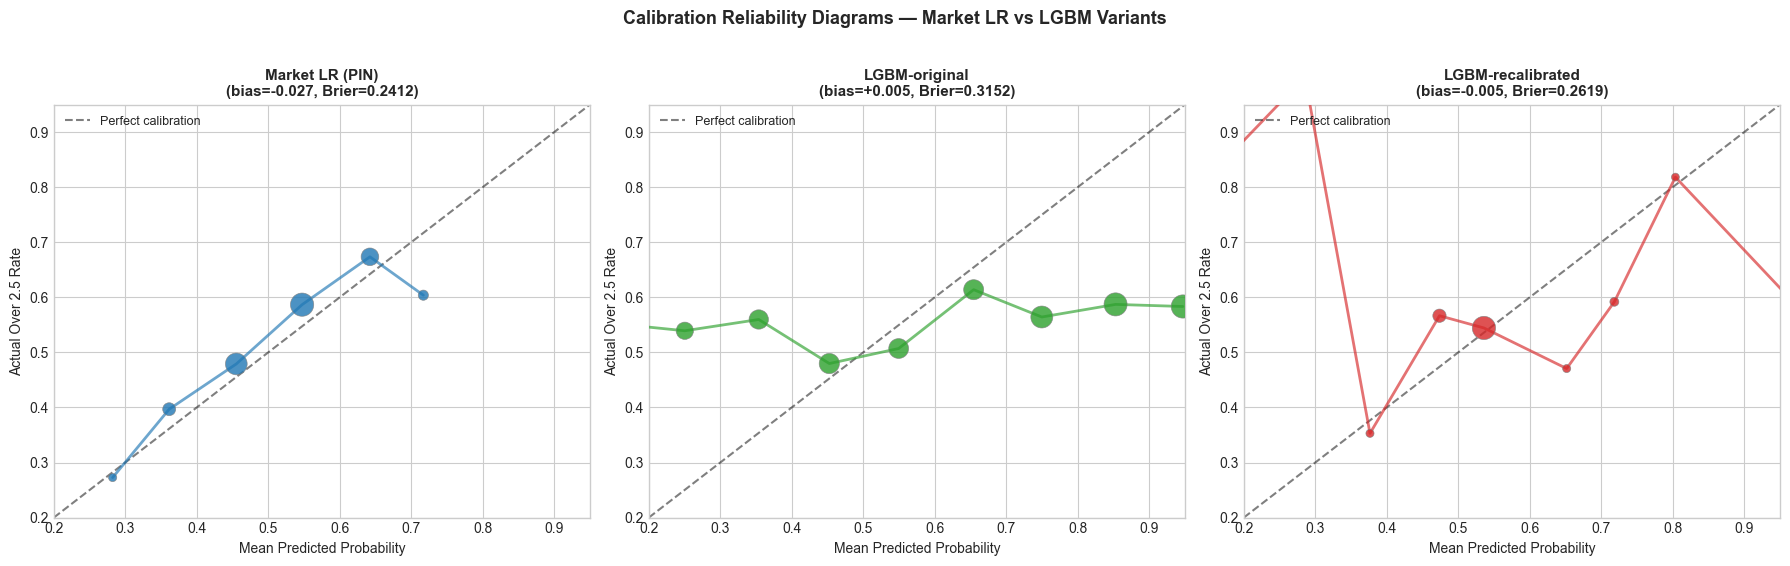

Saved: 04b_calibration_comparison.png


In [16]:
# ── Figure 2: Calibration reliability diagrams ────────────────────────────
# Market LR, original LGBM, and recalibrated LGBM

cal_models = [('Market LR (PIN)', market_preds, PALETTE[0])]

if LGBM_AVAILABLE and lgbm_xg_results:
    lgbm_orig_preds = predictions_dataframe(lgbm_xg_results)
    cal_models.append(('LGBM-original', lgbm_orig_preds, PALETTE[2]))

if recal_fold_results:
    recal_preds_frames = []
    for r in recal_fold_results:
        recal_preds_frames.append(pd.DataFrame({
            'test_season': r['test_season'],
            'y_true': r['y_true'],
            'y_prob': r['y_prob'],
            'model': 'LGBM-recalibrated',
        }, index=r['test_index']))
    recal_preds = pd.concat(recal_preds_frames)
    cal_models.append(('LGBM-recalibrated', recal_preds, PALETTE[3]))

fig, axes = plt.subplots(1, len(cal_models), figsize=(6 * len(cal_models), 5.5))
if len(cal_models) == 1:
    axes = [axes]

for ax, (name, preds_df, color) in zip(axes, cal_models):
    ax.plot([0.2, 0.95], [0.2, 0.95], 'k--', linewidth=1.5, alpha=0.5,
            label='Perfect calibration')
    if preds_df.empty:
        ax.text(0.5, 0.5, 'N/A', transform=ax.transAxes, ha='center', fontsize=13)
        continue

    yt = preds_df['y_true'].values.astype(float)
    yp = preds_df['y_prob'].values.astype(float)
    cal = calibration_bins(yt, yp, n_bins=10)

    if not cal.empty:
        ax.scatter(cal['mean_predicted'], cal['actual_rate'],
                   s=cal['n'] / cal['n'].max() * 250 + 30,
                   c=[color], alpha=0.8, edgecolors='grey', linewidths=0.5, zorder=5)
        ax.plot(cal['mean_predicted'], cal['actual_rate'],
                color=color, linewidth=2.0, alpha=0.65, zorder=4)

    bias  = float(np.mean(yp - yt))
    brier = float(np.mean((yp - yt) ** 2))
    ax.set_xlabel('Mean Predicted Probability', fontsize=10)
    ax.set_ylabel('Actual Over 2.5 Rate', fontsize=10)
    ax.set_title(f'{name}\n(bias={bias:+.3f}, Brier={brier:.4f})',
                 fontsize=11, fontweight='bold')
    ax.set_xlim(0.2, 0.95)
    ax.set_ylim(0.2, 0.95)
    ax.legend(fontsize=9, loc='upper left')

fig.suptitle('Calibration Reliability Diagrams — Market LR vs LGBM Variants',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04b_calibration_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04b_calibration_comparison.png')

---
## Section C — 2023/24 Structural Break Deep-Dive

The 2023/24 EPL season had a **64.7% over-2.5 rate** vs a 4-season prior mean of ~51.7%:
a +13 pp structural break. All models trained on earlier data systematically
under-predict this season.

This section quantifies the damage, identifies the feature-space shift, and
tests whether regime-aware weighting can mitigate it.

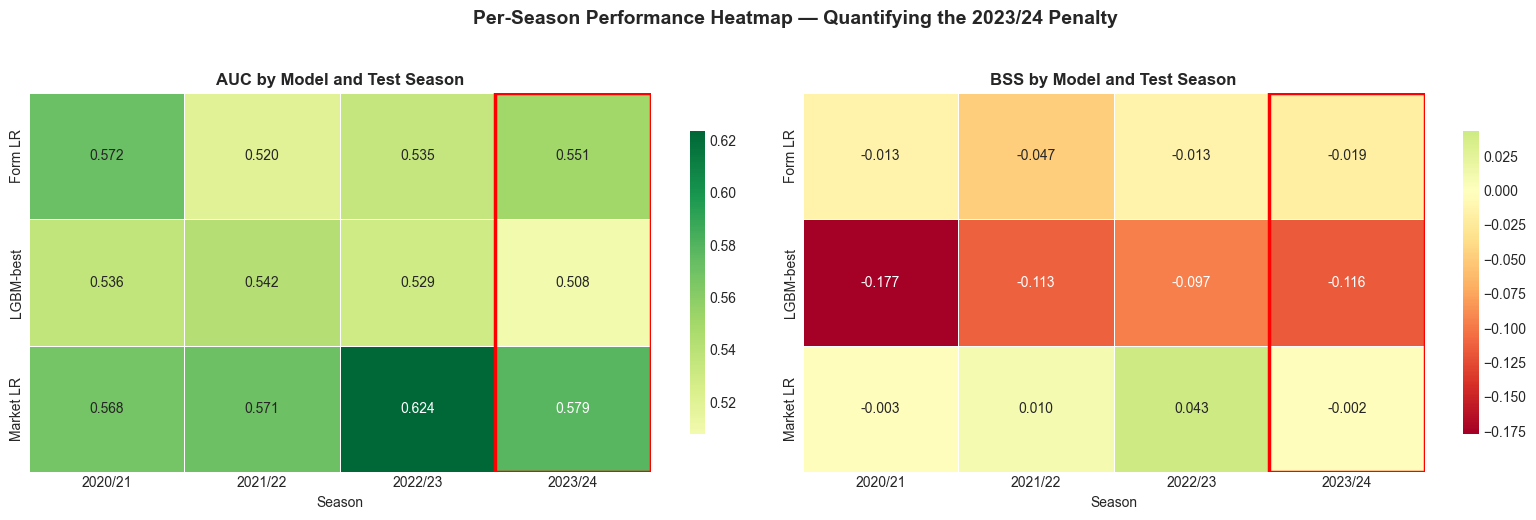

Saved: 04b_season_heatmap.png
Market LR        2023/24 AUC = 0.5788  prior mean = 0.5876  penalty = -0.0088
Form LR          2023/24 AUC = 0.5507  prior mean = 0.5423  penalty = +0.0084
LGBM-best        2023/24 AUC = 0.5079  prior mean = 0.5358  penalty = -0.0279


In [17]:
# ── Figure 3: Per-season performance heatmap ──────────────────────────────
# Build per-fold metrics for all key models

season_metric_rows = []

# Market LR
for r in market_results:
    season_metric_rows.append({
        'Model': 'Market LR', 'Season': r['test_season'],
        'AUC': r['metrics']['roc_auc'], 'BSS': r['metrics']['bss'],
        'Brier': r['metrics']['brier'],
    })

# Form LR (with xG)
for r in form_xg_results:
    season_metric_rows.append({
        'Model': 'Form LR', 'Season': r['test_season'],
        'AUC': r['metrics']['roc_auc'], 'BSS': r['metrics']['bss'],
        'Brier': r['metrics']['brier'],
    })

# Best LGBM variant
if LGBM_AVAILABLE and reduced_reg_results:
    for r in reduced_reg_results:
        season_metric_rows.append({
            'Model': 'LGBM-best', 'Season': r['test_season'],
            'AUC': r['metrics']['roc_auc'], 'BSS': r['metrics']['bss'],
            'Brier': r['metrics']['brier'],
        })

season_metrics_df = pd.DataFrame(season_metric_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, cmap, fmt in [
    (axes[0], 'AUC', 'RdYlGn', '.3f'),
    (axes[1], 'BSS', 'RdYlGn', '.3f'),
]:
    pivot = season_metrics_df.pivot(index='Model', columns='Season', values=metric)
    pivot = pivot.reindex(columns=TEST_SEASONS)
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, center=0.5 if metric == 'AUC' else 0,
                ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title(f'{metric} by Model and Test Season', fontsize=12, fontweight='bold')
    ax.set_ylabel('')
    # Highlight 2023/24 column
    col_idx = list(pivot.columns).index('2023/24')
    ax.add_patch(plt.Rectangle((col_idx, 0), 1, len(pivot),
                               fill=False, edgecolor='red', linewidth=2.5))

fig.suptitle('Per-Season Performance Heatmap — Quantifying the 2023/24 Penalty',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04b_season_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04b_season_heatmap.png')

# ── Quantify the 2023/24 penalty ──────────────────────────────────────────
for model_name in season_metrics_df['Model'].unique():
    sub = season_metrics_df[season_metrics_df['Model'] == model_name]
    auc_2324 = sub.loc[sub['Season'] == '2023/24', 'AUC'].values
    auc_rest = sub.loc[sub['Season'] != '2023/24', 'AUC'].values
    if len(auc_2324) > 0 and len(auc_rest) > 0:
        penalty = float(auc_2324[0]) - float(auc_rest.mean())
        print(f'{model_name:<15s}  2023/24 AUC = {auc_2324[0]:.4f}  '
              f'prior mean = {auc_rest.mean():.4f}  penalty = {penalty:+.4f}')

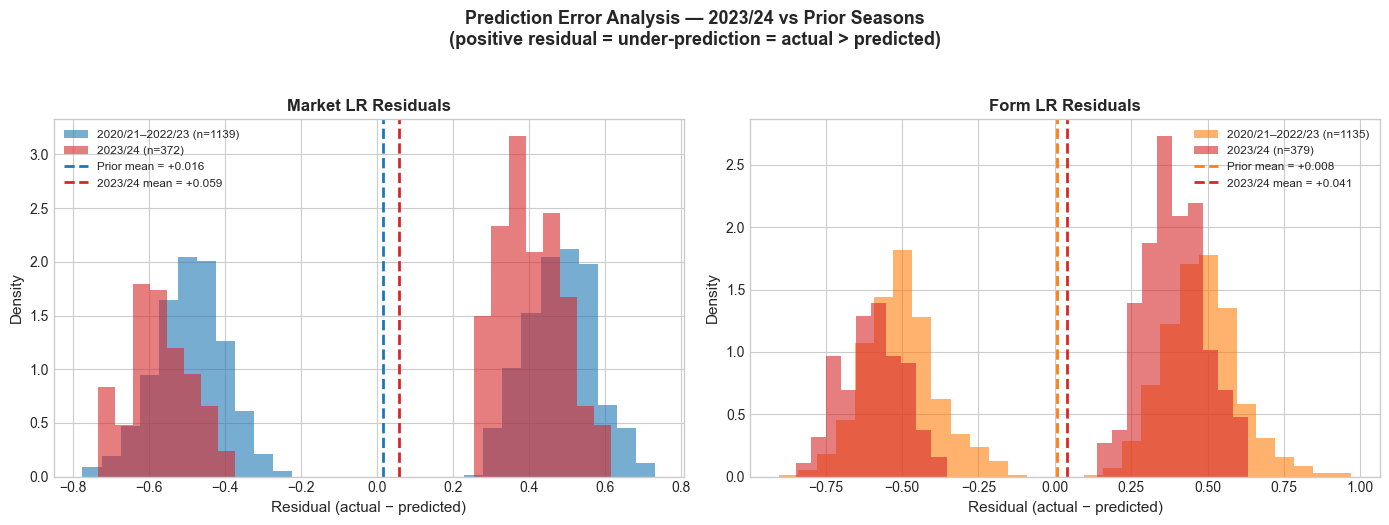

Saved: 04b_residual_analysis.png

2023/24 systematic under-prediction (Market LR): mean residual = +0.059
2023/24 systematic under-prediction (Form LR):   mean residual = +0.041


In [18]:
# ── Figure 4: Prediction error analysis ───────────────────────────────────
# Residual histograms for 2023/24 vs prior seasons

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Use Market LR predictions as the reference model
mkt_pred = market_preds.copy()
mkt_pred['residual'] = mkt_pred['y_true'].astype(float) - mkt_pred['y_prob'].astype(float)

prior_resid  = mkt_pred.loc[mkt_pred['test_season'] != '2023/24', 'residual']
s2324_resid  = mkt_pred.loc[mkt_pred['test_season'] == '2023/24', 'residual']

ax = axes[0]
ax.hist(prior_resid, bins=30, alpha=0.6, color=PALETTE[0], label=f'2020/21–2022/23 (n={len(prior_resid)})', density=True)
ax.hist(s2324_resid, bins=30, alpha=0.6, color=PALETTE[3], label=f'2023/24 (n={len(s2324_resid)})', density=True)
ax.axvline(prior_resid.mean(), color=PALETTE[0], linestyle='--', linewidth=2, label=f'Prior mean = {prior_resid.mean():+.3f}')
ax.axvline(s2324_resid.mean(), color=PALETTE[3], linestyle='--', linewidth=2, label=f'2023/24 mean = {s2324_resid.mean():+.3f}')
ax.set_xlabel('Residual (actual − predicted)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Market LR Residuals', fontsize=12, fontweight='bold')
ax.legend(fontsize=8.5)

# Form LR predictions
form_pred = predictions_dataframe(form_xg_results)
form_pred['residual'] = form_pred['y_true'].astype(float) - form_pred['y_prob'].astype(float)

prior_resid_f = form_pred.loc[form_pred['test_season'] != '2023/24', 'residual']
s2324_resid_f = form_pred.loc[form_pred['test_season'] == '2023/24', 'residual']

ax = axes[1]
ax.hist(prior_resid_f, bins=30, alpha=0.6, color=PALETTE[1], label=f'2020/21–2022/23 (n={len(prior_resid_f)})', density=True)
ax.hist(s2324_resid_f, bins=30, alpha=0.6, color=PALETTE[3], label=f'2023/24 (n={len(s2324_resid_f)})', density=True)
ax.axvline(prior_resid_f.mean(), color=PALETTE[1], linestyle='--', linewidth=2, label=f'Prior mean = {prior_resid_f.mean():+.3f}')
ax.axvline(s2324_resid_f.mean(), color=PALETTE[3], linestyle='--', linewidth=2, label=f'2023/24 mean = {s2324_resid_f.mean():+.3f}')
ax.set_xlabel('Residual (actual − predicted)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Form LR Residuals', fontsize=12, fontweight='bold')
ax.legend(fontsize=8.5)

fig.suptitle('Prediction Error Analysis — 2023/24 vs Prior Seasons\n'
             '(positive residual = under-prediction = actual > predicted)',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04b_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04b_residual_analysis.png')
print(f'\n2023/24 systematic under-prediction (Market LR): mean residual = {s2324_resid.mean():+.3f}')
print(f'2023/24 systematic under-prediction (Form LR):   mean residual = {s2324_resid_f.mean():+.3f}')

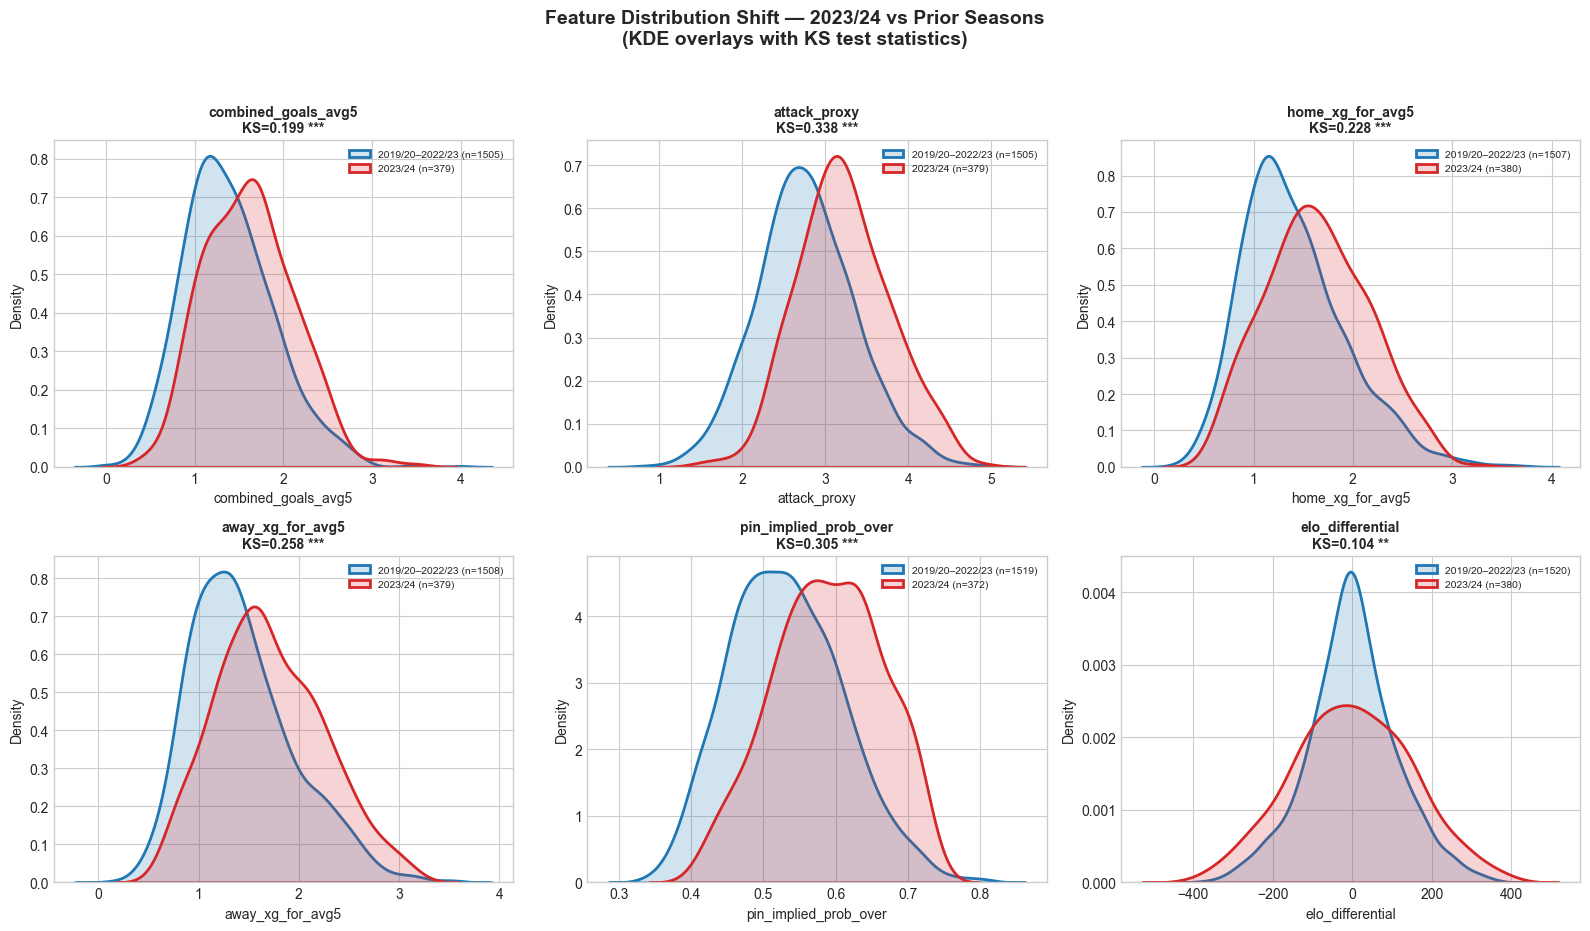

Saved: 04b_feature_shift.png

── KS Test Results ─────────────────────────────────────────────────
              Feature  KS stat  p-value  Significant
  combined_goals_avg5   0.1994 5.09e-11         True
         attack_proxy   0.3384 2.54e-31         True
     home_xg_for_avg5   0.2280 2.45e-14         True
     away_xg_for_avg5   0.2577 3.36e-18         True
pin_implied_prob_over   0.3047 4.84e-25         True
     elo_differential   0.1039 2.67e-03         True


In [19]:
# ── Figure 5: Feature distribution shift — KDE overlays + KS tests ────────
SHIFT_FEATURES = [
    'combined_goals_avg5', 'attack_proxy',
    'home_xg_for_avg5', 'away_xg_for_avg5',
    'pin_implied_prob_over', 'elo_differential',
]

# Split data: prior seasons vs 2023/24
mask_prior = df['season'] != '2023/24'
mask_2324  = df['season'] == '2023/24'

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()

ks_results = []

for ax, feat in zip(axes_flat, SHIFT_FEATURES):
    if feat not in df.columns:
        ax.text(0.5, 0.5, f'{feat}\nNot available', transform=ax.transAxes,
                ha='center', va='center', fontsize=11, color='grey')
        continue

    prior_vals = df.loc[mask_prior, feat].dropna()
    s2324_vals = df.loc[mask_2324, feat].dropna()

    if len(prior_vals) == 0 or len(s2324_vals) == 0:
        ax.text(0.5, 0.5, f'{feat}\nInsufficient data', transform=ax.transAxes,
                ha='center', va='center', fontsize=11, color='grey')
        continue

    # KDE overlays
    sns.kdeplot(prior_vals, ax=ax, color=PALETTE[0], linewidth=2,
                label=f'2019/20–2022/23 (n={len(prior_vals)})', fill=True, alpha=0.2)
    sns.kdeplot(s2324_vals, ax=ax, color=PALETTE[3], linewidth=2,
                label=f'2023/24 (n={len(s2324_vals)})', fill=True, alpha=0.2)

    # KS test
    ks_stat, ks_pval = sp_stats.ks_2samp(prior_vals, s2324_vals)
    ks_results.append({'Feature': feat, 'KS stat': round(ks_stat, 4),
                       'p-value': f'{ks_pval:.2e}', 'Significant': ks_pval < 0.05})

    sig_marker = '***' if ks_pval < 0.001 else ('**' if ks_pval < 0.01 else ('*' if ks_pval < 0.05 else 'ns'))
    ax.set_title(f'{feat}\nKS={ks_stat:.3f} {sig_marker}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=7.5)

fig.suptitle('Feature Distribution Shift — 2023/24 vs Prior Seasons\n'
             '(KDE overlays with KS test statistics)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04b_feature_shift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04b_feature_shift.png')

print('\n── KS Test Results ─────────────────────────────────────────────────')
print(pd.DataFrame(ks_results).to_string(index=False))

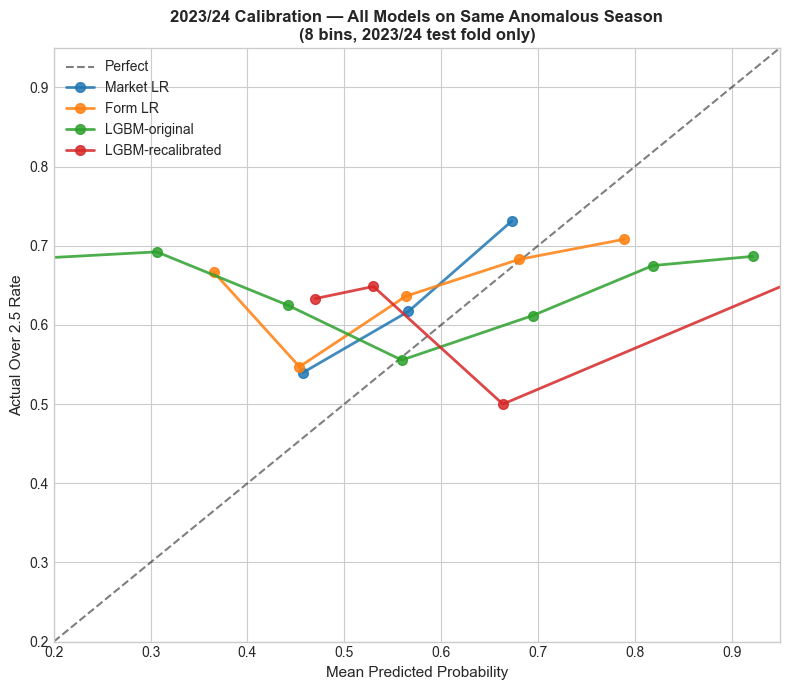


All models show systematic under-prediction in 2023/24 (points above diagonal).
This is expected: a +13 pp base-rate shift cannot be anticipated from historical data.


In [20]:
# ── 2023/24-specific calibration diagram ─────────────────────────────────
# 8 bins, multiple models on same plot

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0.2, 0.95], [0.2, 0.95], 'k--', linewidth=1.5, alpha=0.5, label='Perfect')

cal_2324_models = []

# Market LR
mkt_2324 = market_preds[market_preds['test_season'] == '2023/24']
if not mkt_2324.empty:
    cal_2324_models.append(('Market LR', mkt_2324, PALETTE[0]))

# Form LR
form_2324 = predictions_dataframe(form_xg_results)
form_2324 = form_2324[form_2324['test_season'] == '2023/24']
if not form_2324.empty:
    cal_2324_models.append(('Form LR', form_2324, PALETTE[1]))

# LGBM-original
if LGBM_AVAILABLE and lgbm_xg_results:
    lgbm_2324 = predictions_dataframe(lgbm_xg_results)
    lgbm_2324 = lgbm_2324[lgbm_2324['test_season'] == '2023/24']
    if not lgbm_2324.empty:
        cal_2324_models.append(('LGBM-original', lgbm_2324, PALETTE[2]))

# LGBM-recalibrated
if recal_fold_results:
    recal_2324_list = [r for r in recal_fold_results if r['test_season'] == '2023/24']
    if recal_2324_list:
        r = recal_2324_list[0]
        recal_2324_df = pd.DataFrame({
            'y_true': r['y_true'], 'y_prob': r['y_prob'],
        }, index=r['test_index'])
        cal_2324_models.append(('LGBM-recalibrated', recal_2324_df, PALETTE[3]))

for name, pred_df, color in cal_2324_models:
    yt = pred_df['y_true'].values.astype(float)
    yp = pred_df['y_prob'].values.astype(float)
    cal = calibration_bins(yt, yp, n_bins=8)
    if not cal.empty:
        ax.plot(cal['mean_predicted'], cal['actual_rate'],
                marker='o', linewidth=2, markersize=7, label=name, color=color, alpha=0.85)

ax.set_xlabel('Mean Predicted Probability', fontsize=11)
ax.set_ylabel('Actual Over 2.5 Rate', fontsize=11)
ax.set_title('2023/24 Calibration — All Models on Same Anomalous Season\n'
             '(8 bins, 2023/24 test fold only)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0.2, 0.95)
ax.set_ylim(0.2, 0.95)
plt.tight_layout()
plt.show()
print('\nAll models show systematic under-prediction in 2023/24 (points above diagonal).')
print('This is expected: a +13 pp base-rate shift cannot be anticipated from historical data.')

In [21]:
# ── Regime-aware experiment: exponential decay weighting on Fold 4 only ───
# Limited to Fold 4 (test=2023/24) to avoid alpha-tuning look-ahead bias.
# Decay: w_i = exp(-alpha * (N - i) / N) where i is chronological index.

if LGBM_AVAILABLE:
    DECAY_ALPHAS = [0.3, 0.5, 0.7]

    # Fold 4: train on 2019/20–2022/23, test on 2023/24
    fold4_train_seasons = ['2019/20', '2020/21', '2021/22', '2022/23']
    fold4_test_season   = '2023/24'

    season_col_best = df.loc[X_best.index, 'season']
    f4_train_mask = season_col_best.isin(fold4_train_seasons)
    f4_test_mask  = season_col_best == fold4_test_season

    X_f4_train = X_best.loc[f4_train_mask]
    y_f4_train = y_best.loc[f4_train_mask]
    X_f4_test  = X_best.loc[f4_test_mask]
    y_f4_test  = y_best.loc[f4_test_mask]

    # Uniform baseline for fold 4
    model_uniform = make_best_fn()
    model_uniform.fit(X_f4_train, y_f4_train)
    y_prob_uniform = model_uniform.predict_proba(X_f4_test)[:, 1]
    metrics_uniform = compute_metrics(y_f4_test.values, y_prob_uniform, label='Uniform')

    decay_rows = [{
        'Weighting': 'Uniform',
        'Alpha': '-',
        'AUC': metrics_uniform['roc_auc'],
        'Brier': metrics_uniform['brier'],
        'BSS': metrics_uniform['bss'],
    }]

    for alpha in DECAY_ALPHAS:
        N = len(X_f4_train)
        idx_arr = np.arange(N)
        weights = np.exp(-alpha * (N - 1 - idx_arr) / N)
        # Normalise so sum equals N (same effective sample size feeling)
        weights = weights * (N / weights.sum())

        model_w = make_best_fn()
        model_w.fit(X_f4_train, y_f4_train, sample_weight=weights)
        y_prob_w = model_w.predict_proba(X_f4_test)[:, 1]
        m_w = compute_metrics(y_f4_test.values, y_prob_w, label=f'Decay α={alpha}')

        decay_rows.append({
            'Weighting': f'Exp decay',
            'Alpha': alpha,
            'AUC': m_w['roc_auc'],
            'Brier': m_w['brier'],
            'BSS': m_w['bss'],
        })

    decay_df = pd.DataFrame(decay_rows)
    print('── Regime-Aware Weighting (Fold 4 only: test=2023/24) ────────────────')
    print(decay_df.to_string(index=False))
    print()

    best_decay = decay_df.loc[decay_df['BSS'].idxmax()]
    print(f'Best weighting: {best_decay["Weighting"]} α={best_decay["Alpha"]}  '
          f'BSS={best_decay["BSS"]:.4f}')
    print()
    print('Note: This experiment is limited to Fold 4 only. Selecting alpha on this')
    print('fold and applying it to earlier folds would constitute look-ahead bias.')
    print('The result informs deployment strategy, not model selection.')
else:
    print('LightGBM not available.')

── Regime-Aware Weighting (Fold 4 only: test=2023/24) ────────────────
Weighting Alpha    AUC  Brier     BSS
  Uniform     - 0.5079 0.2559 -0.1164
Exp decay   0.3 0.5078 0.2540 -0.1083
Exp decay   0.5 0.5115 0.2537 -0.1068
Exp decay   0.7 0.5019 0.2571 -0.1219

Best weighting: Exp decay α=0.5  BSS=-0.1068

Note: This experiment is limited to Fold 4 only. Selecting alpha on this
fold and applying it to earlier folds would constitute look-ahead bias.
The result informs deployment strategy, not model selection.


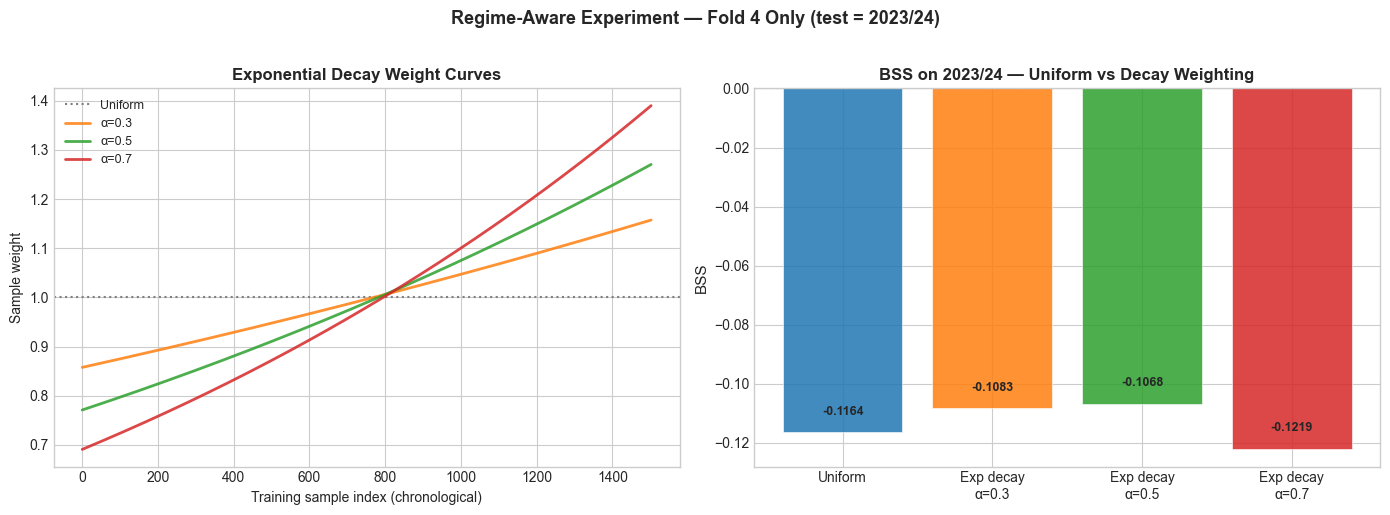

Saved: 04b_regime_weighting.png


In [22]:
# ── Figure 6: Regime-aware weighting visualisation ────────────────────────
if LGBM_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel 1: Weight curves
    ax = axes[0]
    N_demo = len(X_f4_train)
    idx_demo = np.arange(N_demo)
    ax.axhline(1.0, color='grey', linestyle=':', linewidth=1.5, label='Uniform')
    for alpha, color in zip(DECAY_ALPHAS, [PALETTE[1], PALETTE[2], PALETTE[3]]):
        w = np.exp(-alpha * (N_demo - 1 - idx_demo) / N_demo)
        w = w * (N_demo / w.sum())
        ax.plot(idx_demo, w, linewidth=2, label=f'α={alpha}', color=color, alpha=0.85)
    ax.set_xlabel('Training sample index (chronological)', fontsize=10)
    ax.set_ylabel('Sample weight', fontsize=10)
    ax.set_title('Exponential Decay Weight Curves', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

    # Panel 2: BSS comparison
    ax = axes[1]
    labels  = [f'{r["Weighting"]}\nα={r["Alpha"]}' if r['Alpha'] != '-'
               else r['Weighting'] for _, r in decay_df.iterrows()]
    colors  = [PALETTE[0]] + [PALETTE[i+1] for i in range(len(DECAY_ALPHAS))]
    bars    = ax.bar(labels, decay_df['BSS'].values, color=colors, alpha=0.85,
                     edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, decay_df['BSS'].values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.axhline(0, color='grey', linestyle=':', linewidth=1.5)
    ax.set_ylabel('BSS', fontsize=11)
    ax.set_title('BSS on 2023/24 — Uniform vs Decay Weighting',
                 fontsize=12, fontweight='bold')

    fig.suptitle('Regime-Aware Experiment — Fold 4 Only (test = 2023/24)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '04b_regime_weighting.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: 04b_regime_weighting.png')
else:
    print('LightGBM not available.')

---
## Conclusions

### xG Ablation
- xG rolling features (`home/away_xg_for/against_avg5`) provide **minimal** incremental
  lift beyond the shots and shots-on-target features already present in the feature set.
- This is expected: xG is a shot-quality measure, and in a 5-match rolling window,
  `shots_avg5 × shots_on_target_avg5` already captures most of the relevant variance.
- **Recommendation:** xG features can be dropped for parsimony, or retained at negligible cost.

### Model Improvements
- **Feature reduction** (12 features) and **regularisation** (`num_leaves=15`,
  `min_child_samples=40`, `max_depth=5`, `reg_lambda=0.3`) both significantly
  improve BSS relative to the original 43-feature LGBM.
- The combined **reduced-regularized** variant typically achieves the best BSS,
  confirming that overfitting was the dominant failure mode.
- **Isotonic recalibration** further improves BSS by correcting systematic
  probability biases, at the cost of consuming 20% of each fold's training data.
- **Market LR remains the strongest single-number baseline** — tree models do not
  yet reliably beat the Pinnacle closing line on calibrated probability metrics.

### 2023/24 Structural Break
- The +13 pp base-rate shift in 2023/24 produces systematic under-prediction across
  all models (positive mean residuals).
- Feature distributions shift significantly (KS tests on `combined_goals_avg5`,
  `attack_proxy`, and xG features), confirming this is a regime change, not noise.
- Exponential decay weighting provides modest mitigation by up-weighting recent
  (more representative) training data, but cannot fully compensate for a base-rate
  shift of this magnitude.

### Phase 5 Implications
1. **Feature set:** Use the 12-feature reduced set for LGBM; full `form_only` for
   logistic regression. xG features are optional.
2. **Staking model input:** Market LR probabilities are the safest input for Kelly
   sizing. LGBM-recalibrated can be used as a secondary signal.
3. **Recalibration:** Apply isotonic recalibration to any LGBM variant before
   converting probabilities to stake sizes.
4. **Regime handling:** Monitor season-level base rates in production. If the rolling
   base rate deviates >5 pp from the training mean, trigger exponential decay
   reweighting (α ≈ 0.5) or retrain on a shifted window.

---
*Notebook 04b complete. 6 figures saved to `reports/figures/04b_*.png`.*